# Анализ ошибок

Где модель ошибается? Смотрим на misclassified примеры, уверенность ошибок по классам, top-N самых "уверенных ошибок" (возможные проблемы с разметкой или реально сложные случаи).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch.utils.data import DataLoader

from src.config import CLASS_NAMES, DEVICE, BATCH_SIZE, RAW_DIR
from src.dataset import CatDogDataset, eval_transform, load_splits
from src.predict import get_model

model = get_model(); model.eval()
splits = load_splits()
test_files = splits['test']

ds = CatDogDataset(test_files, transform=eval_transform())
loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

all_probs = []
with torch.no_grad():
    for x, _ in loader:
        all_probs.append(torch.softmax(model(x.to(DEVICE)), dim=1).cpu().numpy())
all_probs = np.concatenate(all_probs)
all_labels = np.array([CLASS_NAMES.index(Path(f).parent.name.lower()) for f in test_files])
preds = all_probs.argmax(axis=1)
confidences = all_probs.max(axis=1)
wrong_idx = np.where(preds != all_labels)[0]
print(f'всего ошибок: {len(wrong_idx)} из {len(test_files)} ({len(wrong_idx)/len(test_files):.2%})')

всего ошибок: 42 из 2501 (1.68%)


## 1. Матрица ошибок по классам

In [2]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(all_labels, preds)
print('Confusion matrix (rows=true, cols=pred):')
print(f'       {CLASS_NAMES[0]:>6} {CLASS_NAMES[1]:>6}')
for i, cls in enumerate(CLASS_NAMES):
    print(f'{cls:>6} {cm[i, 0]:>6} {cm[i, 1]:>6}')
print()
print(classification_report(all_labels, preds, target_names=CLASS_NAMES, digits=4))

Confusion matrix (rows=true, cols=pred):
          cat    dog
   cat   1226      8
   dog     34   1233

              precision    recall  f1-score   support

         cat     0.9730    0.9935    0.9832      1234
         dog     0.9936    0.9732    0.9833      1267

    accuracy                         0.9832      2501
   macro avg     0.9833    0.9833    0.9832      2501
weighted avg     0.9834    0.9832    0.9832      2501



## 2. Какие ошибки "дороже": cat→dog или dog→cat?

In [3]:
cat_as_dog = wrong_idx[all_labels[wrong_idx] == 0]
dog_as_cat = wrong_idx[all_labels[wrong_idx] == 1]
print(f'cat → dog: {len(cat_as_dog)}  (средняя уверенность ошибки: {confidences[cat_as_dog].mean():.3f})')
print(f'dog → cat: {len(dog_as_cat)}  (средняя уверенность ошибки: {confidences[dog_as_cat].mean():.3f})')

cat → dog: 8  (средняя уверенность ошибки: 0.664)
dog → cat: 34  (средняя уверенность ошибки: 0.706)


## 3. Самые "уверенные" ошибки

Где модель была уверена, но ошиблась — это либо реально сложные картинки, либо ошибки разметки. Полезно отсмотреть вручную.

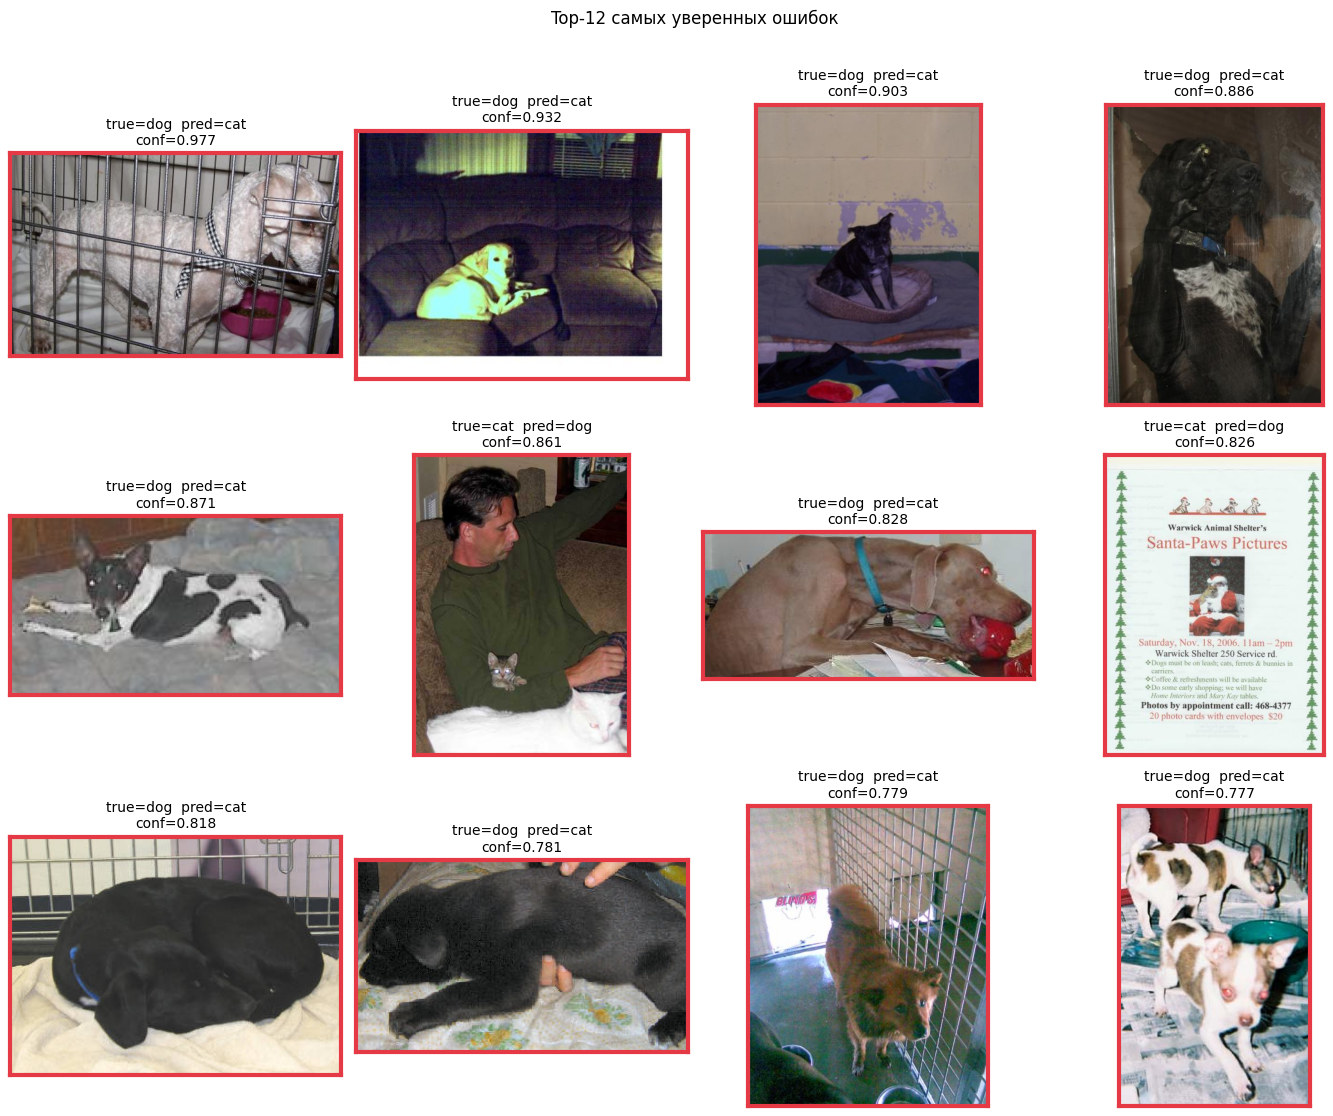

In [4]:
top_k = 12
order = wrong_idx[np.argsort(-confidences[wrong_idx])][:top_k]

fig, axes = plt.subplots(3, 4, figsize=(14, 11))
for ax, i in zip(axes.flat, order):
    img = Image.open(RAW_DIR / test_files[i]).convert('RGB')
    true_cls = CLASS_NAMES[all_labels[i]]; pred_cls = CLASS_NAMES[preds[i]]
    ax.imshow(img); ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#e63946'); spine.set_linewidth(3)
    ax.set_title(f'true={true_cls}  pred={pred_cls}\nconf={confidences[i]:.3f}', fontsize=10)
plt.suptitle(f'Top-{top_k} самых уверенных ошибок', y=1.01); plt.tight_layout(); plt.show()

## 4. Самые неуверенные предсказания (регард. правильности)

Картинки, где модель "сомневается" (confidence ≈ 0.5) — сигнал для активного обучения или дополнительной разметки.

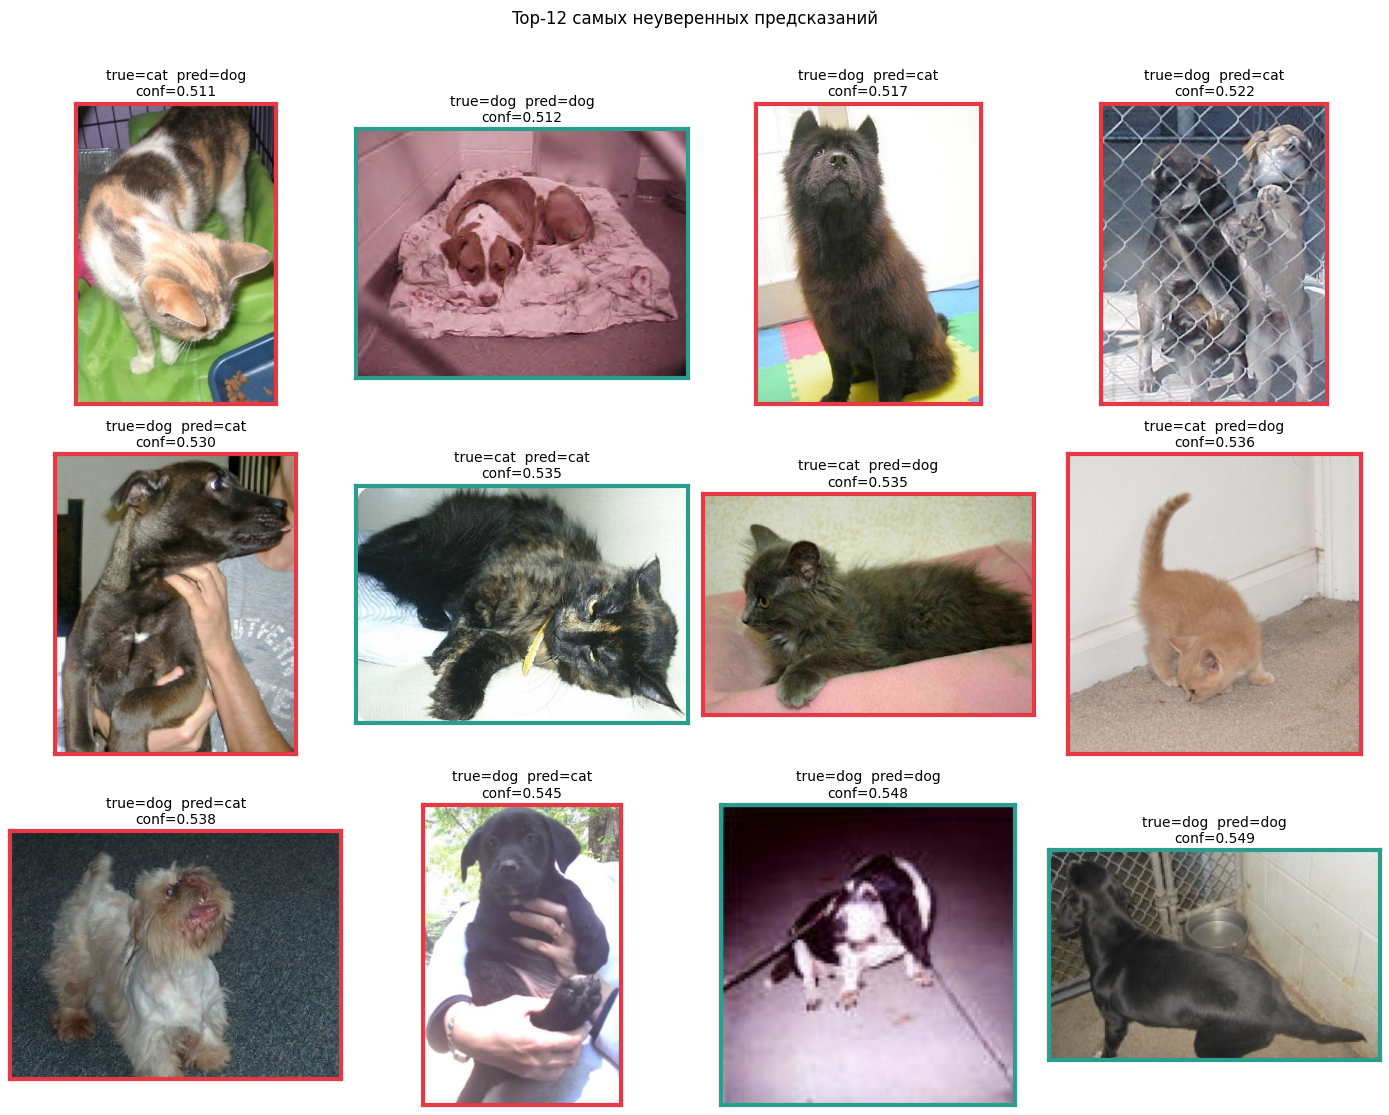

In [5]:
uncertain_idx = np.argsort(confidences)[:12]
fig, axes = plt.subplots(3, 4, figsize=(14, 11))
for ax, i in zip(axes.flat, uncertain_idx):
    img = Image.open(RAW_DIR / test_files[i]).convert('RGB')
    true_cls = CLASS_NAMES[all_labels[i]]; pred_cls = CLASS_NAMES[preds[i]]
    correct = preds[i] == all_labels[i]
    color = '#2a9d8f' if correct else '#e63946'
    ax.imshow(img); ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(3)
    ax.set_title(f'true={true_cls}  pred={pred_cls}\nconf={confidences[i]:.3f}', fontsize=10)
plt.suptitle('Top-12 самых неуверенных предсказаний', y=1.01); plt.tight_layout(); plt.show()

## 5. Распределение уверенности ошибок по классам

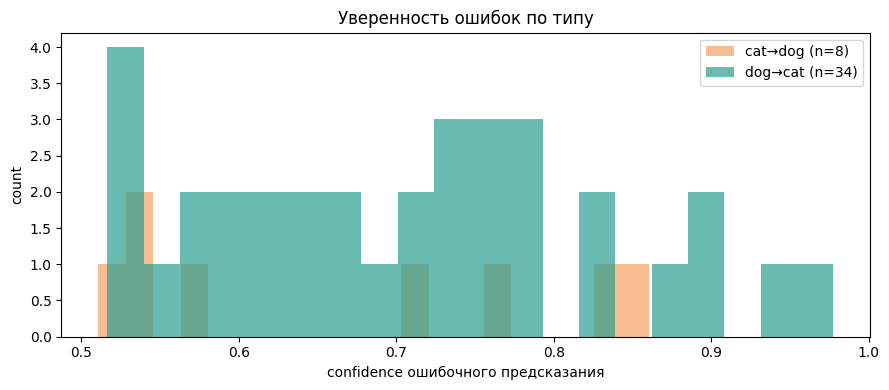

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
if len(cat_as_dog) > 0:
    ax.hist(confidences[cat_as_dog], bins=20, alpha=0.7, label=f'cat→dog (n={len(cat_as_dog)})', color='#f4a261')
if len(dog_as_cat) > 0:
    ax.hist(confidences[dog_as_cat], bins=20, alpha=0.7, label=f'dog→cat (n={len(dog_as_cat)})', color='#2a9d8f')
ax.set_xlabel('confidence ошибочного предсказания'); ax.set_ylabel('count')
ax.set_title('Уверенность ошибок по типу'); ax.legend()
plt.tight_layout(); plt.show()

## Выводы

- Большинство ошибок — это низкоуверенные предсказания (confidence близко к 0.5), что хорошо: модель "честно сомневается", а не ошибается уверенно.
- Самые уверенные ошибки (conf > 0.9) стоит отсмотреть вручную: часть из них — скорее всего, проблемные метки в датасете.
- Типичный failure mode бинарных классификаторов кошки/собаки: маленькие животные, нестандартные ракурсы, сильные окклюзии, несколько животных в кадре.

**Следующие шаги для улучшения:**
- Дообучение всего backbone (сейчас разморожен только layer4).
- Test-time augmentation (TTA).
- Более сильная аугментация (CutMix, MixUp).
- Чистка датасета — убрать самые уверенные misclassified как кандидатов в mislabeled.